<a href="https://colab.research.google.com/github/Zahraalavi2415/Zahraalavi2415.github.io/blob/main/Copy_of_MCMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

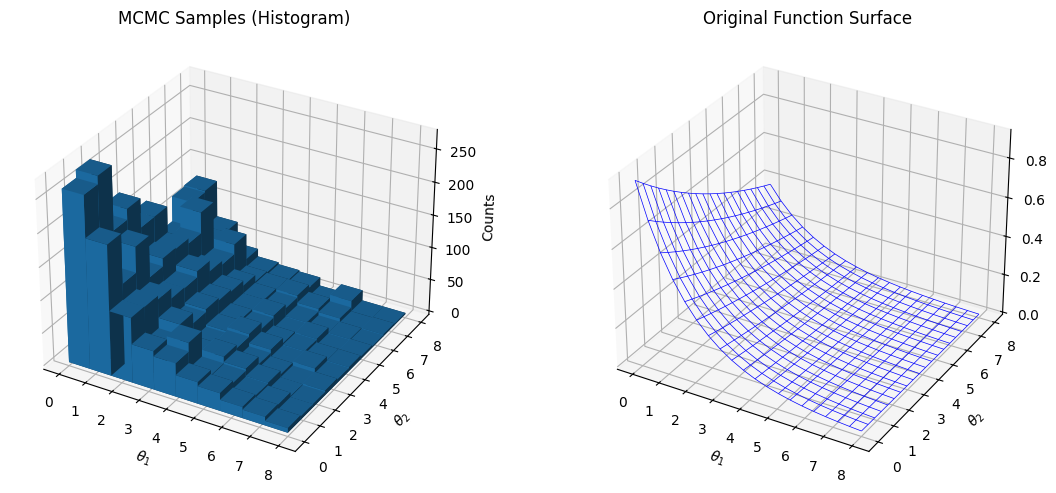

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Tabe bivexp (az file bivexp.m) ---
def bivexp(theta1, theta2):
    lambda1 = 0.5
    lambda2 = 0.1
    lambd = 0.01
    maxval = 8
    # Formool-e moadele dar MATLAB
    return np.exp(-(lambda1 + lambd) * theta1 - (lambda2 + lambd) * theta2 - lambd * maxval)

# --- Tanzimat-e اولیه (az file BWU.m) ---
T = 5000
thetamin = np.array([0, 0])
thetamax = np.array([8, 8])

# Set seed baraye yeksan boodan-e natayej
np.random.seed(1)

theta = np.zeros((2, T))
theta[0, 0] = np.random.uniform(thetamin[0], thetamax[1])
theta[1, 0] = np.random.uniform(thetamin[1], thetamax[1])

# --- BWU Sampling (Metropolis-Hastings) ---
for t in range(1, T):
    # Tolid-e pishnahad (Proposal)
    theta_star = np.random.uniform(thetamin, thetamax)

    # Mohasebe-ye nesbat-e paziresh (Acceptance Ratio)
    numerator = bivexp(theta_star[0], theta_star[1])
    denominator = bivexp(theta[0, t-1], theta[1, t-1])

    fraction = numerator / denominator
    alpha = min(1, fraction)

    # Paziresh ya rad-e pishnahad
    u = np.random.rand()
    if u < alpha:
        theta[:, t] = theta_star
    else:
        theta[:, t] = theta[:, t-1]

# --- Plot (Namayesh-e Natayej) ---
fig = plt.figure(figsize=(12, 5))

# Subplot 1: Histogram 3D (Moshabeh-e hist3)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
nbins = 10
hist, xedges, yedges = np.histogram2d(theta[0, :], theta[1, :], bins=nbins,
                                     range=[[thetamin[0], thetamax[0]], [thetamin[1], thetamax[1]]])

# Sakht-e mokatab-ha baraye histogram
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = 0

dx = dy = (thetamax[0] - thetamin[0]) / nbins
dz = hist.ravel()

ax1.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_2$')
ax1.set_zlabel('Counts')
ax1.set_title('MCMC Samples (Histogram)')

# Subplot 2: Mesh Plot (Tave-ye asli)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
nbins_mesh = 20
thetabins1 = np.linspace(thetamin[0], thetamax[0], nbins_mesh)
thetabins2 = np.linspace(thetamin[1], thetamax[1], nbins_mesh)
theta1grid, theta2grid = np.meshgrid(thetabins1, thetabins2)
ygrid = bivexp(theta1grid, theta2grid)

ax2.plot_wireframe(theta1grid, theta2grid, ygrid, color='blue', linewidth=0.5)
ax2.set_xlabel('$\\theta_1$')
ax2.set_ylabel('$\\theta_2$')
ax2.set_title('Original Function Surface')

plt.tight_layout()
plt.show()


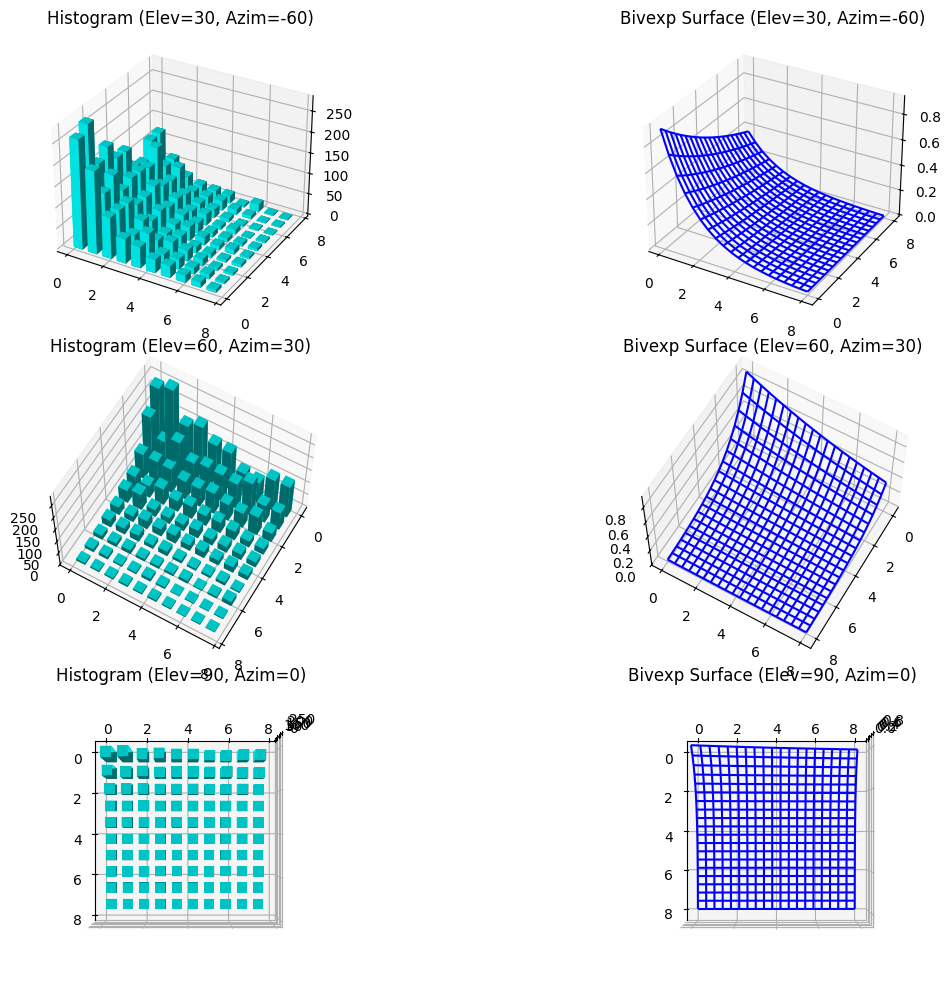

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Functions (Az file-haye voroodi) ---
def bivexp(theta1, theta2):
    # Parameter-haye tarif shode dar bivexp.m
    lambda1, lambda2, lambd, maxval = 0.5, 0.1, 0.01, 8
    return np.exp(-(lambda1 + lambd) * theta1 - (lambda2 + lambd) * theta2 - lambd * maxval)

# --- Sampling Logic (Az file BWU.m) ---
T = 5000
thetamin, thetamax = np.array([0, 0]), np.array([8, 8])
np.random.seed(1)
theta = np.zeros((2, T))
theta[:, 0] = np.random.uniform(0, 8, 2)

for t in range(1, T):
    theta_star = np.random.uniform(thetamin, thetamax)
    fraction = bivexp(theta_star[0], theta_star[1]) / bivexp(theta[0, t-1], theta[1, t-1])
    if np.random.rand() < min(1, fraction):
        theta[:, t] = theta_star
    else:
        theta[:, t] = theta[:, t-1]

# --- Rasm dar 3 Zaviye-ye Mokhtalef ---
zavaya = [(30, -60), (60, 30), (90, 0)] # (Elevation, Azimuth)
fig = plt.figure(figsize=(15, 10))

for i, (elev, azim) in enumerate(zavaya):
    # 1. Histogram Samples (Samt-e Chap)
    ax1 = fig.add_subplot(3, 2, 2*i + 1, projection='3d')
    hist, xedges, yedges = np.histogram2d(theta[0, :], theta[1, :], bins=10)
    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
    ax1.bar3d(xpos.ravel(), ypos.ravel(), 0, 0.5, 0.5, hist.ravel(), color='cyan')
    ax1.view_init(elev=elev, azim=azim)
    ax1.set_title(f'Histogram (Elev={elev}, Azim={azim})')

    # 2. Mesh Tabe (Samt-e Rast)
    ax2 = fig.add_subplot(3, 2, 2*i + 2, projection='3d')
    t1 = np.linspace(0, 8, 20); t2 = np.linspace(0, 8, 20)
    T1, T2 = np.meshgrid(t1, t2)
    ax2.plot_wireframe(T1, T2, bivexp(T1, T2), color='blue')
    ax2.view_init(elev=elev, azim=azim)
    ax2.set_title(f'Bivexp Surface (Elev={elev}, Azim={azim})')

plt.tight_layout()
plt.show()